# Customer Lifetime Value (LTV) Modeling

## Objective

Estimate the expected future lifetime value of active customers using survival analysis and current monthly charges.

In [1]:
import pandas as pd
df=pd.read_csv("../data/processed/telco_customer_churn_cleaned.csv")
df.head()

,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,LTV
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,29.85
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,1936.30
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,107.70
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,1903.50
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,141.40


In [2]:
df.shape

(7043, 22)

In [3]:
df[["CustomerID", "Tenure", "Churn", "MonthlyCharges"]].head()

,CustomerID,Tenure,Churn,MonthlyCharges
0,7590-VHVEG,1,No,29.85
1,5575-GNVDE,34,No,56.95
2,3668-QPYBK,2,Yes,53.85
3,7795-CFOCW,45,No,42.30
4,9237-HQITU,2,Yes,70.70


In [4]:
df[["Tenure", "MonthlyCharges"]].dtypes

Tenure              int64
MonthlyCharges    float64
dtype: object

In [5]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

## Survival Analysis Preparation

For survival analysis:
- Tenure represents the observed duration.
- Churn indicates whether the churn event occurred.
- Active customers are treated as censored observations.

In [6]:
survival_df = df[["Tenure", "Churn"]].copy()
survival_df["event"] = (survival_df["Churn"] == "Yes").astype(int)

survival_df.head()

,Tenure,Churn,event
0,1,No,0
1,34,No,0
2,2,Yes,1
3,45,No,0
4,2,Yes,1


In [7]:
survival_df["event"].value_counts()

event
0    5174
1    1869
Name: count, dtype: int64

In [8]:
%pip install lifelines

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
#Lifelines: a Python library designed for survival analysis.
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()

kmf.fit(
    durations=survival_df["Tenure"],
    event_observed=survival_df["event"]
)

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 7043 total observations, 5174 right-censored observations>

In [10]:
kmf.survival_function_.head()

,KM_estimate
timeline,
0.0,1.000000
1.0,0.945961
2.0,0.927835
3.0,0.913725
4.0,0.901045


- timeline = tenure
- KM_estimate = estimated probability of a customer surviving beyond that point

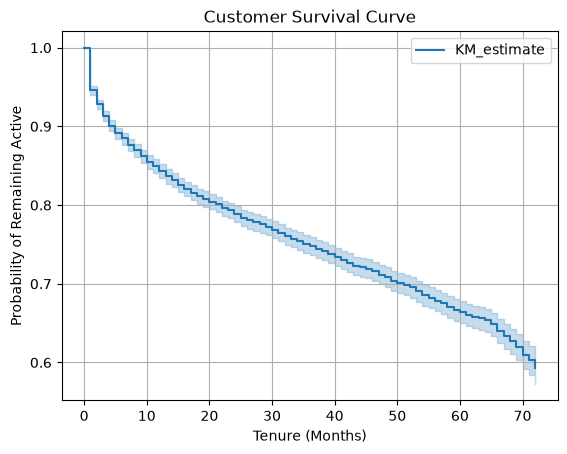

In [11]:
import matplotlib.pyplot as plt

kmf.plot_survival_function()

plt.title("Customer Survival Curve")
plt.xlabel("Tenure (Months)")
plt.ylabel("Probability of Remaining Active")
plt.grid(True)
plt.show()

In [12]:
df.columns

Index(['CustomerID', 'Gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'Tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'LTV'],
      dtype='object')

In [13]:
cox_df = df.drop(
    ["CustomerID", "Tenure", "Churn", "TotalCharges", "LTV"],
    axis=1
).copy()

cox_df["Tenure"] = df["Tenure"]
cox_df["event"] = (df["Churn"] == "Yes").astype(int)

cox_df.head()

,Gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Tenure,event
0,Female,No,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,1,0
1,Male,No,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,34,0
2,Male,No,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,2,1
3,Male,No,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,45,0
4,Female,No,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,2,1


In [14]:
cox_df.columns

Index(['Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'Tenure', 'event'],
      dtype='object')

In [16]:
categorical_features = cox_df.select_dtypes(include="object").columns

categorical_features

Index(['Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

### One-hot encoding

In [18]:
#converting values to 0/1
cox_encoded = pd.get_dummies(
    cox_df,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)
cox_encoded.head()

,MonthlyCharges,Tenure,event,Gender_Male,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,29.85,1,0,0,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
1,56.95,34,0,1,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,53.85,2,1,1,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,42.30,45,0,1,0,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,70.70,2,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0


In [19]:
cox_encoded.shape

(7043, 30)

In [20]:
cox_encoded.columns

Index(['MonthlyCharges', 'Tenure', 'event', 'Gender_Male', 'SeniorCitizen_Yes',
       'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [21]:
cox_encoded.isna().sum().sum()

np.int64(0)

In [23]:
duplicate_columns = cox_encoded.T.duplicated()

cox_encoded.columns[duplicate_columns]

Index(['OnlineSecurity_No internet service',
       'OnlineBackup_No internet service',
       'DeviceProtection_No internet service',
       'TechSupport_No internet service', 'StreamingTV_No internet service',
       'StreamingMovies_No internet service'],
      dtype='object')

In [25]:
#removing duplicate columns:TO RUN COX MODEL
duplicate_columns = cox_encoded.T.duplicated()

cox_encoded_clean = cox_encoded.loc[:, ~duplicate_columns]

In [26]:
cox_encoded_clean.shape

(7043, 24)

In [27]:
cox_encoded_clean.T.duplicated().sum()

np.int64(0)

In [30]:
cox_encoded_clean.nunique().sort_values()

Gender_Male                                 2
event                                       2
Partner_Yes                                 2
SeniorCitizen_Yes                           2
Dependents_Yes                              2
PhoneService_Yes                            2
MultipleLines_Yes                           2
MultipleLines_No phone service              2
OnlineSecurity_Yes                          2
OnlineBackup_Yes                            2
InternetService_Fiber optic                 2
InternetService_No                          2
DeviceProtection_Yes                        2
TechSupport_Yes                             2
StreamingMovies_Yes                         2
StreamingTV_Yes                             2
PaperlessBilling_Yes                        2
PaymentMethod_Credit card (automatic)       2
Contract_One year                           2
Contract_Two year                           2
PaymentMethod_Electronic check              2
PaymentMethod_Mailed check        

In [32]:
import numpy as np
corr = cox_encoded_clean.corr().abs()

high_corr = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

high_corr.stack().sort_values(ascending=False).head(20)

PhoneService_Yes                MultipleLines_No phone service    1.000000
MonthlyCharges                  InternetService_Fiber optic       0.787066
                                InternetService_No                0.763557
                                StreamingTV_Yes                   0.629603
                                StreamingMovies_Yes               0.627429
Tenure                          Contract_Two year                 0.558533
StreamingTV_Yes                 StreamingMovies_Yes               0.533094
MonthlyCharges                  MultipleLines_Yes                 0.490434
                                DeviceProtection_Yes              0.482692
InternetService_Fiber optic     InternetService_No                0.465793
Partner_Yes                     Dependents_Yes                    0.452676
MonthlyCharges                  OnlineBackup_Yes                  0.441780
InternetService_No              StreamingMovies_Yes               0.418675
                         

**NOTE** - PhoneService_Yes , MultipleLines_No phone service contain same info so remove one

In [33]:
cox_encoded_clean = cox_encoded_clean.drop(
    columns=["MultipleLines_No phone service"]
)

In [34]:
cox_encoded_clean.shape

(7043, 23)

## Cox Proportional Hazards Model

The Cox Proportional Hazards model is a survival analysis model used to understand how different customer characteristics affect the risk of churn over time.

In this project, the model uses customer information such as contract type, services, payment method, MonthlyCharges, and other features to estimate how each factor influences the customer's risk of leaving.

The model also accounts for customers who are still active, whose exact churn time is unknown. This allows us to use both churned and active customers when estimating customer survival and expected remaining lifetime.

In [35]:
from lifelines import CoxPHFitter

cph = CoxPHFitter()

cph.fit(
    cox_encoded_clean,
    duration_col="Tenure",
    event_col="event"
)

<lifelines.CoxPHFitter: fitted with 7043 total observations, 5174 right-censored observations>

## Interpreting Cox Model Results

The Cox model estimates how each customer characteristic affects the risk of churn over time.

The `exp(coef)` value is the **hazard ratio**:
- Hazard ratio > 1 → higher churn risk
- Hazard ratio < 1 → lower churn risk
- Hazard ratio ≈ 1 → little effect on churn risk

The `p` value helps determine whether the relationship is statistically significant. A small p-value (typically < 0.05) indicates stronger evidence that the feature is associated with churn risk.

We will use these results to identify the factors that increase or decrease customer churn risk before estimating customer survival and remaining lifetime.

In [36]:
cph.summary

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
MonthlyCharges,-0.008035,0.991997,0.022902,-0.052921,0.036851,0.948455,1.037539,0.0,-0.350847,7.257034e-01,0.462548
Gender_Male,-0.085483,0.918068,0.046437,-0.176498,0.005531,0.838200,1.005547,0.0,-1.840849,6.564370e-02,3.929200
SeniorCitizen_Yes,-0.071278,0.931203,0.056574,-0.182161,0.039606,0.833467,1.040400,0.0,-1.259900,2.077056e-01,2.267388
Partner_Yes,-0.518013,0.595703,0.055114,-0.626036,-0.409991,0.534707,0.663656,0.0,-9.398867,5.515353e-21,67.297037
Dependents_Yes,-0.053813,0.947609,0.068817,-0.188691,0.081065,0.828042,1.084442,0.0,-0.781977,4.342282e-01,1.203475
PhoneService_Yes,0.254869,1.290293,0.471464,-0.669183,1.178922,0.512127,3.250868,0.0,0.540591,5.887892e-01,0.764177
MultipleLines_Yes,-0.417913,0.658419,0.126211,-0.665281,-0.170545,0.514129,0.843205,0.0,-3.311238,9.288407e-04,10.072281
InternetService_Fiber optic,0.586660,1.797973,0.575065,-0.540447,1.713766,0.582488,5.549824,0.0,1.020163,3.076513e-01,1.700632
InternetService_No,-1.301150,0.272219,0.585698,-2.449096,-0.153204,0.086372,0.857955,0.0,-2.221538,2.631451e-02,5.247997


In [37]:
cph.summary[["coef", "exp(coef)", "p"]].sort_values("p")

,coef,exp(coef),p
covariate,,,
Contract_Two year,-3.232282,0.039467,1.501291e-85
Contract_One year,-1.615306,0.198830,7.754256e-75
Partner_Yes,-0.518013,0.595703,5.515353e-21
PaymentMethod_Electronic check,0.585874,1.796561,2.156990e-16
PaymentMethod_Mailed check,0.566075,1.761339,1.402522e-10
OnlineBackup_Yes,-0.613068,0.541686,1.370712e-06
OnlineSecurity_Yes,-0.612170,0.542173,4.268605e-06
MultipleLines_Yes,-0.417913,0.658419,9.288407e-04
PaperlessBilling_Yes,0.181481,1.198991,1.364153e-03


### Key Findings from the Cox Model

- The Cox Proportional Hazards model identifies customer characteristics
that are associated with differences in churn risk.

- Features with a hazard ratio below 1 are associated with lower churn
risk, while features with a hazard ratio above 1 are associated with
higher churn risk.

- The strongest significant relationships in this model include contract
type, payment method, online security, online backup, and technical
support.

- Customers with longer-term contracts show substantially lower churn
risk, while customers using electronic check or mailed check payment
methods show higher churn risk compared with their respective reference
categories.

- These findings help explain which customer characteristics are
associated with customer retention and will be used as context for the
next stage of the analysis: estimating customer survival over time.